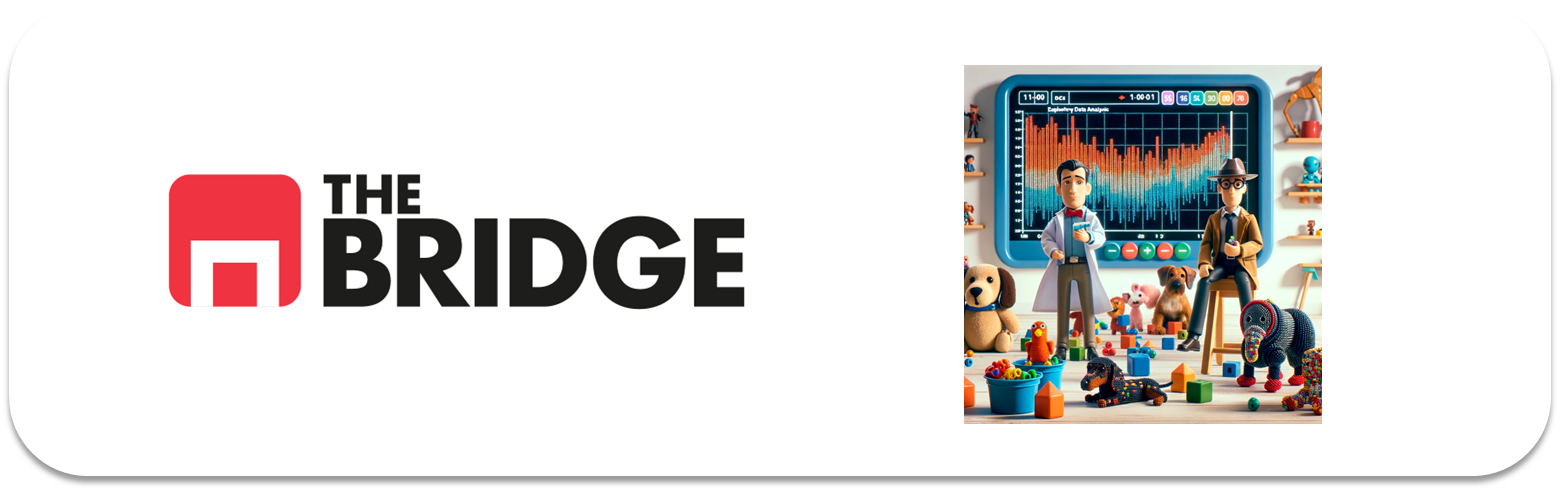

## PRACTICA OBLIGATORIA: **Análisis Multivariante**

* La práctica obligatoria de esta unidad consiste en completar el análisis del dataset del Titanic, dirigido por una serie de preguntas, y de terminar de analizar algunos aspectos del dataset de viajes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0


Importa los paquetes y módulos que necesites a lo largo del notebook

In [135]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from bootcampviztools import plot_categorical_numerical_relationship, plot_combined_graphs, \
    pinta_distribucion_categoricas, grafico_dispersion_con_correlacion, plot_categorical_relationship_fin, plot_grouped_histograms, \
        grafico_dispersion_con_correlacion



## #1: Titanic

### #1.1

Carga en un dataframe el dataset del titanic, que está en la ruta "./data/titanic.csv".

In [97]:
df_titanic = pd.read_csv("./data/titanic.csv")
df_titanic.head(5)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### #1.2

Deshazte de las columnas "deck", "survived", "pclass" y "embarked" porque no las emplearemos, la primera por su cantidad de nulos y el resto porque son variantes de otras que ya existen y cuyos valores resultan más expresivos a la hora de hacer un análisis. 

In [98]:
df_titanic = df_titanic.drop(columns = ["deck", "survived", "pclass", "embarked"])

In [99]:
df_titanic.columns

Index(['sex', 'age', 'sibsp', 'parch', 'fare', 'class', 'who', 'adult_male',
       'embark_town', 'alive', 'alone'],
      dtype='object')

### #1.3

Suma las columnas "parch" y "sibsp" para tener el número de parientes de cada pasajero, guarda el resultado en otra columna "family_members", luego deshazte de "parch" y "sibsp"

In [100]:
df_titanic["family_members"] = df_titanic["parch"] + df_titanic["sibsp"]

In [101]:
df_titanic.sample(5)

,sex,age,sibsp,parch,fare,class,who,adult_male,embark_town,alive,alone,family_members
727,female,NaN,0,0,7.7375,Third,woman,False,Queenstown,yes,True,0
587,male,60.0,1,1,79.2000,First,man,True,Cherbourg,yes,False,2
690,male,31.0,1,0,57.0000,First,man,True,Southampton,yes,False,1
184,female,4.0,0,2,22.0250,Third,child,False,Southampton,yes,False,2
284,male,NaN,0,0,26.0000,First,man,True,Southampton,no,True,0


In [102]:
df_titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sex             891 non-null    object 
 1   age             714 non-null    float64
 2   sibsp           891 non-null    int64  
 3   parch           891 non-null    int64  
 4   fare            891 non-null    float64
 5   class           891 non-null    object 
 6   who             891 non-null    object 
 7   adult_male      891 non-null    bool   
 8   embark_town     889 non-null    object 
 9   alive           891 non-null    object 
 10  alone           891 non-null    bool   
 11  family_members  891 non-null    int64  
dtypes: bool(2), float64(2), int64(3), object(5)
memory usage: 71.5+ KB


In [103]:
df_titanic.describe()

,age,sibsp,parch,fare,family_members
count,714.000000,891.000000,891.000000,891.000000,891.000000
mean,29.699118,0.523008,0.381594,32.204208,0.904602
std,14.526497,1.102743,0.806057,49.693429,1.613459
min,0.420000,0.000000,0.000000,0.000000,0.000000
25%,20.125000,0.000000,0.000000,7.910400,0.000000
50%,28.000000,0.000000,0.000000,14.454200,0.000000
75%,38.000000,1.000000,0.000000,31.000000,1.000000
max,80.000000,8.000000,6.000000,512.329200,10.000000


### #1.4

Imputa la moda a los valores nulos de "embark_town"

In [104]:
df_titanic["embark_town"].mode()[0]

'Southampton'

In [105]:
df_titanic["embark_town"] = df_titanic["embark_town"].fillna(df_titanic["embark_town"].mode()[0])

### #1.5

Imputa la media a los valores faltantes de "age", si quieres puedes hacer algo más preciso (por ejemplo considerando además la columna "who")

In [106]:
df_titanic.loc[df_titanic["who"] == "man", "age"] = df_titanic.loc[(df_titanic["who"] == "man"), "age"].fillna(df_titanic.loc[(df_titanic["who"] == "man"), "age"].mean())

In [107]:
df_titanic.loc[df_titanic["who"] == "child", "age"] = df_titanic.loc[(df_titanic["who"] == "child"), "age"].fillna(df_titanic.loc[(df_titanic["who"] == "child"), "age"].mean())

In [108]:
df_titanic.loc[df_titanic["who"] == "woman", "age"] = df_titanic.loc[(df_titanic["who"] == "woman"), "age"].fillna(df_titanic.loc[(df_titanic["who"] == "woman"), "age"].mean())

### #1.6

Realiza los análisis bivariantes o multivariantes que necesites, así como los test de hipótesis necesarios para contestar a las siguientes preguntas. Nota: utiliza la variable "alive" para saber si un pasajero sobrevivió o no:

1. En términos absolutos, ¿sobrevivieron más hombres, mujeres o niños? **Mujeres** ¿Y en términos relativos? **Mujeres** ¿Existe alguna relación estadísticamente significativa entre el sexo y la supervivencia en el Titanic?**Si**¿Y entre ser adulto o ser niño?

2. En términos absolutos, ¿de que clase sobrevivieron más pasajeros? **First**¿ Y en términos relativos? **First**¿Existe alguna relación estadísticamente significativa entre la clase en la que se viajaba y la supervivencia? **Si**

3. ¿De qué ciudad sobrevivieron más personas?**Southampton**¿Y porcentualmente de que ciudad sobrevivieron más personas?**Southampton** ¿Hay alguna relación estadística significativa entre haber embarcado en una de las tres ciudades y haber sobrevivido o fallecido? **No**

4. ¿Qué relación hay entre el precio del pasaje y la supervivencia/fallecimiento? .La media de coste del pasaje de las personas que sobrevivieron es mayor que las que no.

5. Existen pasajero que no pagaron el billete, ¿podrías explicar por qué? ¿Qué ocurrió con la persona que más dinero se dejó? **Sobrevivió**

6. Existe alguna relación entre el dinero pagado, la ciudad de embarque y la superviviencia/fallecimiento. No necesitas aplicar ningún test, muestralo numérica o visualmente.

7. Ahondando en la relación entre sobrevivir o fallecer, la clase en la que se viajó y la edad de los pasajeros. ¿Qué agrupación de las dos variables (clase y edad) sobrevivió más en términos absolutos y en términos relativos?

8. Finalmente, muestra las posibles relaciones entre edad, coste del billete y supervivencia/fallecimiento. ¿Qué puedes decir al respecto?

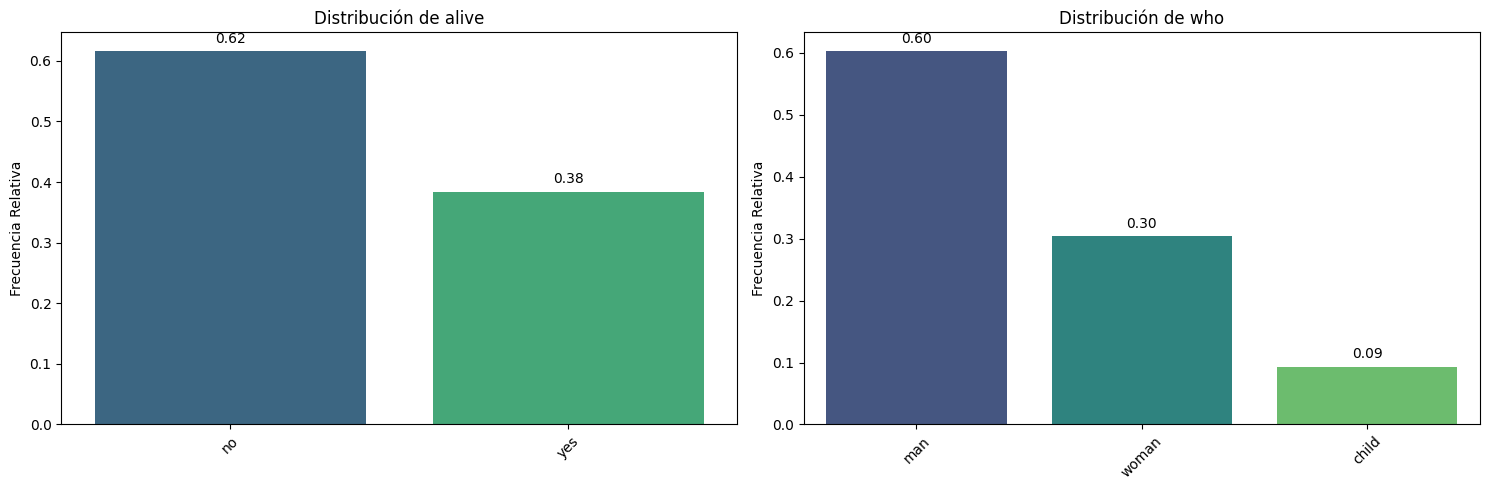

In [109]:
pinta_distribucion_categoricas(df_titanic,["alive","who"], relativa= True, mostrar_valores= True)

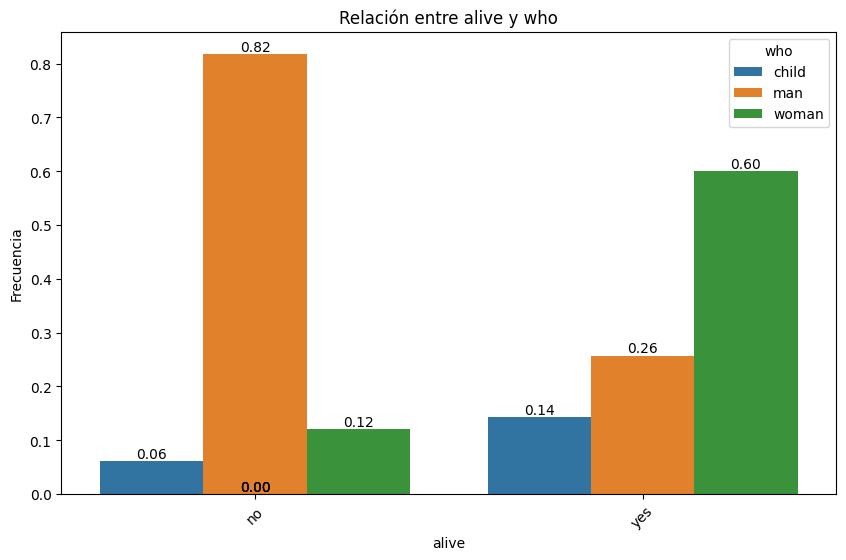

In [110]:
plot_categorical_relationship_fin(df_titanic, "alive","who", relative_freq = True, show_values= True)

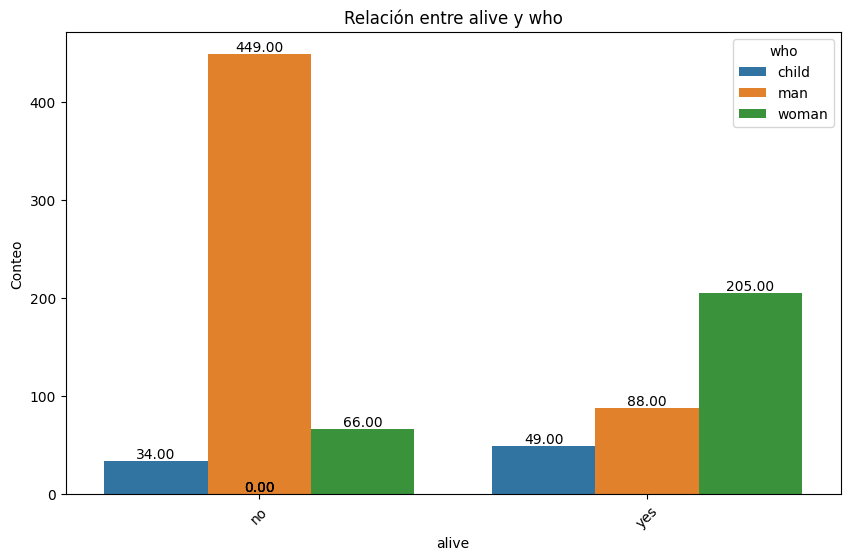

In [111]:
plot_categorical_relationship_fin(df_titanic, "alive","who", show_values= True)

In [112]:
tabla_contingencia = pd.crosstab(df_titanic['alive'], df_titanic['who'])

tabla_contingencia

who,child,man,woman
alive,,,
no,34,449,66
yes,49,88,205


In [113]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(tabla_contingencia)


print("Valor Chi-Cuadrado:", chi2)
print("P-Value:", p)
print("Grados de Libertad:", dof)
print("Tabla de Frecuencias Esperadas:\n", expected)

Valor Chi-Cuadrado: 283.923050324233
P-Value: 2.2227620817798914e-62
Grados de Libertad: 2
Tabla de Frecuencias Esperadas:
 [[ 51.14141414 330.87878788 166.97979798]
 [ 31.85858586 206.12121212 104.02020202]]


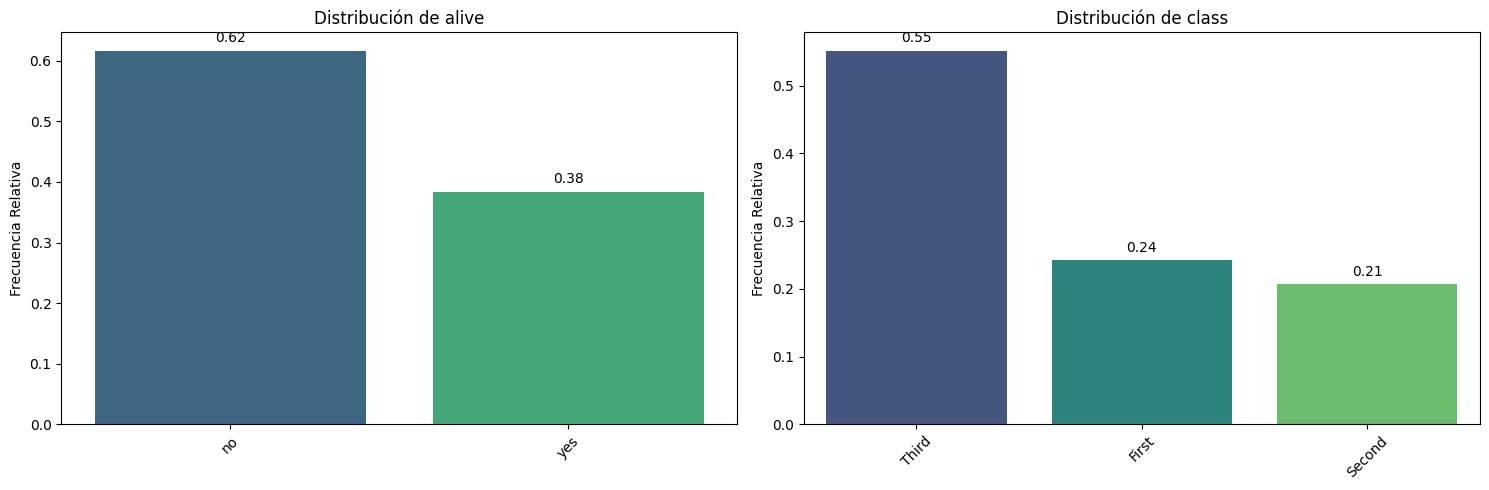

In [114]:
pinta_distribucion_categoricas(df_titanic,["alive","class"], relativa= True, mostrar_valores= True)

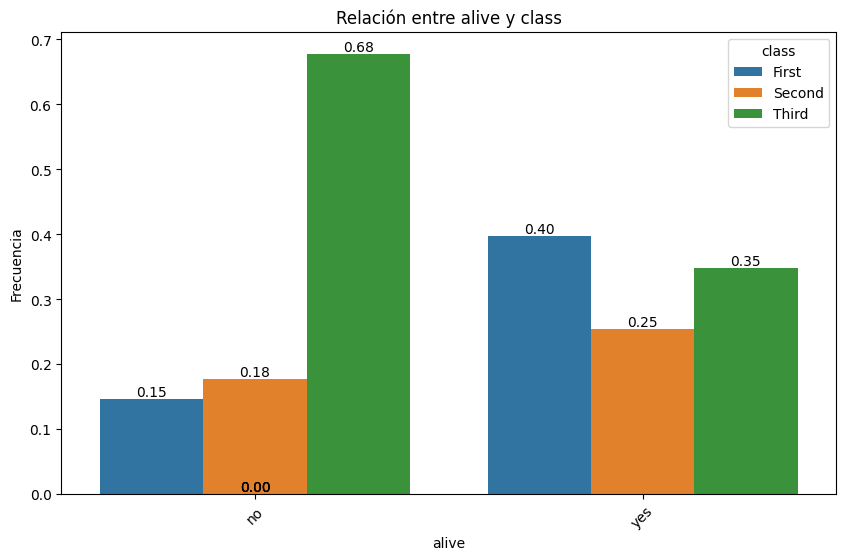

In [115]:
plot_categorical_relationship_fin(df_titanic, "alive","class", relative_freq = True, show_values= True)

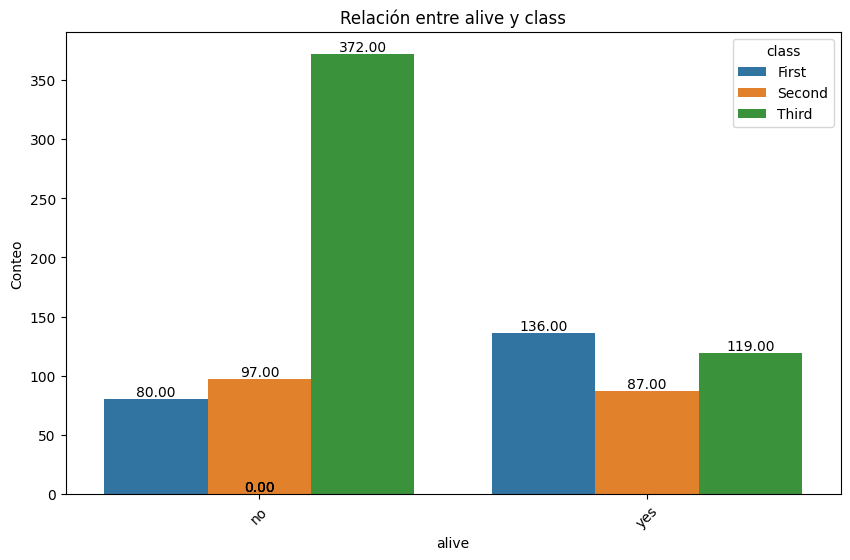

In [116]:
plot_categorical_relationship_fin(df_titanic, "alive","class", show_values= True)


In [117]:
tabla_contingencia = pd.crosstab(df_titanic['alive'], df_titanic['class'])

tabla_contingencia

class,First,Second,Third
alive,,,
no,80,97,372
yes,136,87,119


In [118]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(tabla_contingencia)


print("Valor Chi-Cuadrado:", chi2)
print("P-Value:", p)
print("Grados de Libertad:", dof)
print("Tabla de Frecuencias Esperadas:\n", expected)

Valor Chi-Cuadrado: 102.88898875696056
P-Value: 4.549251711298793e-23
Grados de Libertad: 2
Tabla de Frecuencias Esperadas:
 [[133.09090909 113.37373737 302.53535354]
 [ 82.90909091  70.62626263 188.46464646]]


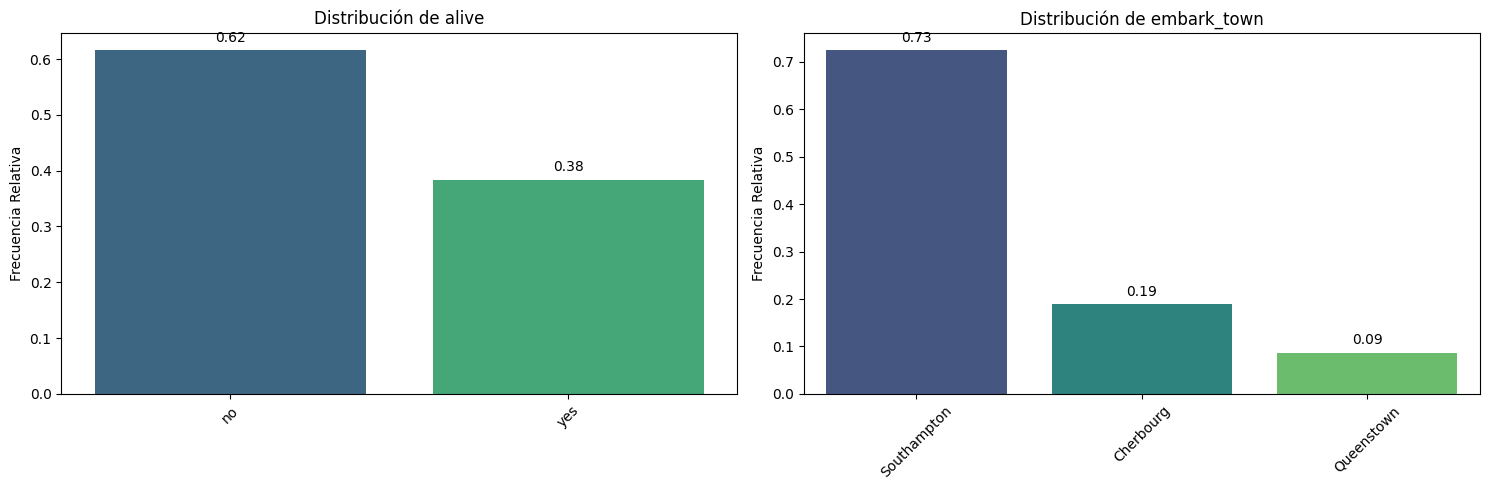

In [119]:
pinta_distribucion_categoricas(df_titanic,["alive","embark_town"], relativa= True, mostrar_valores= True)

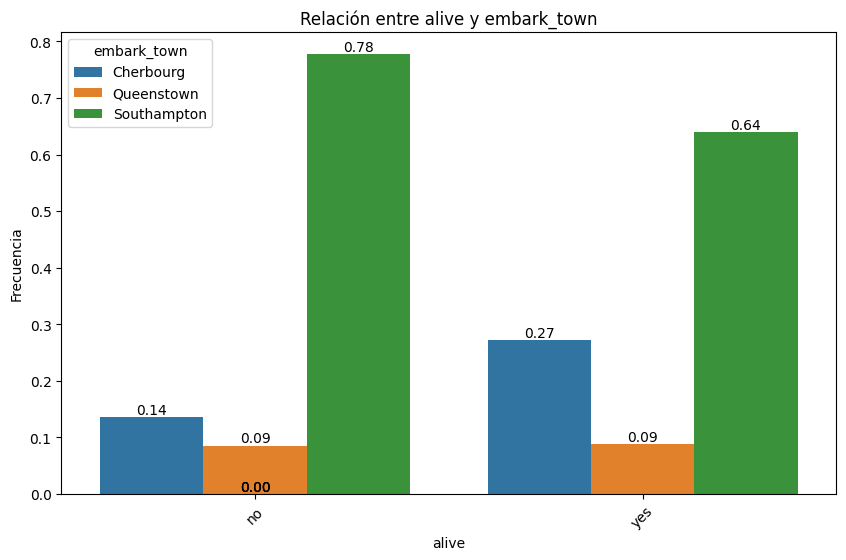

In [120]:
plot_categorical_relationship_fin(df_titanic, "alive","embark_town", relative_freq = True, show_values= True)

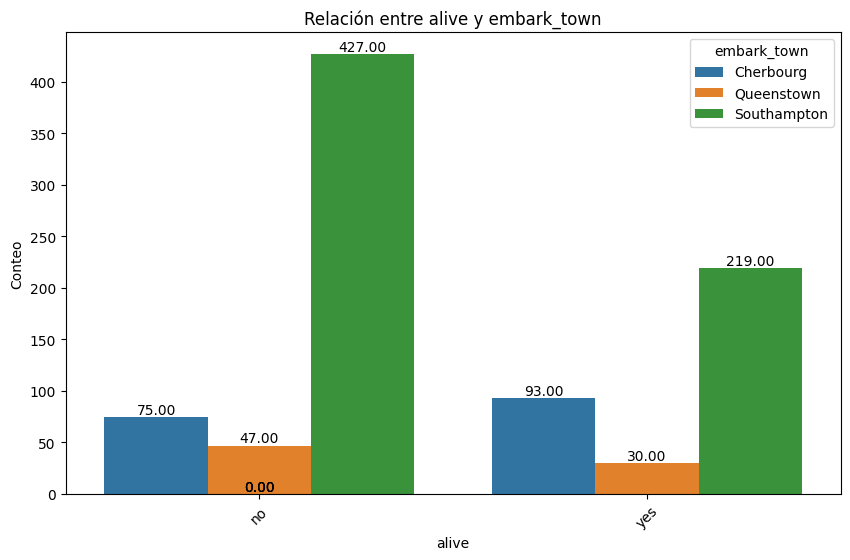

In [121]:
plot_categorical_relationship_fin(df_titanic, "alive","embark_town", show_values= True)


In [122]:
tabla_contingencia = pd.crosstab(df_titanic['alive'], df_titanic['embark_town'])

tabla_contingencia

embark_town,Cherbourg,Queenstown,Southampton
alive,,,
no,75,47,427
yes,93,30,219


In [123]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(tabla_contingencia)


print("Valor Chi-Cuadrado:", chi2)
print("P-Value:", p)
print("Grados de Libertad:", dof)
print("Tabla de Frecuencias Esperadas:\n", expected)

Valor Chi-Cuadrado: 25.964452881874784
P-Value: 2.3008626481449577e-06
Grados de Libertad: 2
Tabla de Frecuencias Esperadas:
 [[103.51515152  47.44444444 398.04040404]
 [ 64.48484848  29.55555556 247.95959596]]


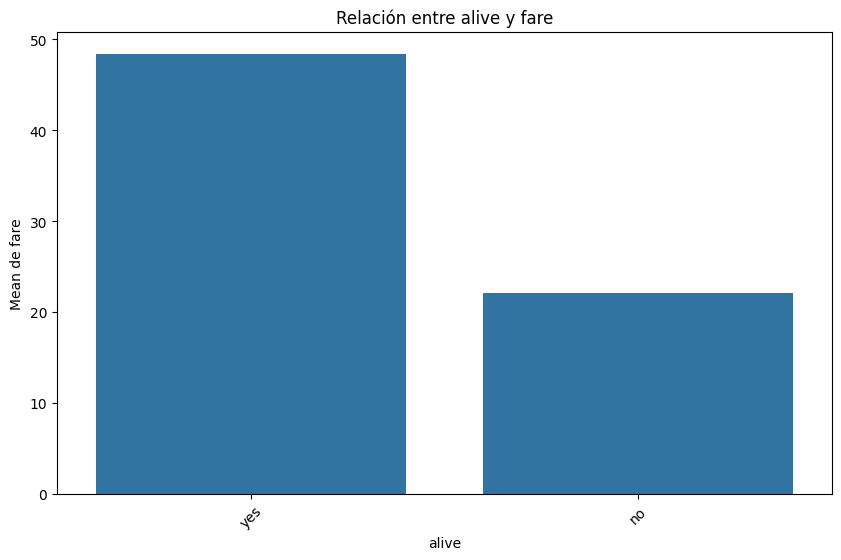

In [124]:
plot_categorical_numerical_relationship(df_titanic, "alive", "fare")

In [125]:
df_titanic.describe()

,age,sibsp,parch,fare,family_members
count,891.000000,891.000000,891.000000,891.000000,891.000000
mean,30.319458,0.523008,0.381594,32.204208,0.904602
std,13.063839,1.102743,0.806057,49.693429,1.613459
min,0.420000,0.000000,0.000000,0.000000,0.000000
25%,22.000000,0.000000,0.000000,7.910400,0.000000
50%,32.000000,0.000000,0.000000,14.454200,0.000000
75%,35.000000,1.000000,0.000000,31.000000,1.000000
max,80.000000,8.000000,6.000000,512.329200,10.000000


In [126]:
df_titanic.loc[df_titanic["fare"] == 0]

,sex,age,sibsp,parch,fare,class,who,adult_male,embark_town,alive,alone,family_members
179,male,36.000000,0,0,0.0,Third,man,True,Southampton,no,True,0
263,male,40.000000,0,0,0.0,First,man,True,Southampton,no,True,0
271,male,25.000000,0,0,0.0,Third,man,True,Southampton,yes,True,0
277,male,33.173123,0,0,0.0,Second,man,True,Southampton,no,True,0
302,male,19.000000,0,0,0.0,Third,man,True,Southampton,no,True,0
413,male,33.173123,0,0,0.0,Second,man,True,Southampton,no,True,0
466,male,33.173123,0,0,0.0,Second,man,True,Southampton,no,True,0
481,male,33.173123,0,0,0.0,Second,man,True,Southampton,no,True,0
597,male,49.000000,0,0,0.0,Third,man,True,Southampton,no,True,0
633,male,33.173123,0,0,0.0,First,man,True,Southampton,no,True,0


In [127]:
df_titanic.loc[df_titanic["fare"].idxmax()]

sex                  female
age                    35.0
sibsp                     0
parch                     0
fare               512.3292
class                 First
who                   woman
adult_male            False
embark_town       Cherbourg
alive                   yes
alone                  True
family_members            0
Name: 258, dtype: object

6. Existe alguna relación entre el dinero pagado, la ciudad de embarque y la superviviencia/fallecimiento. No necesitas aplicar ningún test, muestralo numérica o visualmente.

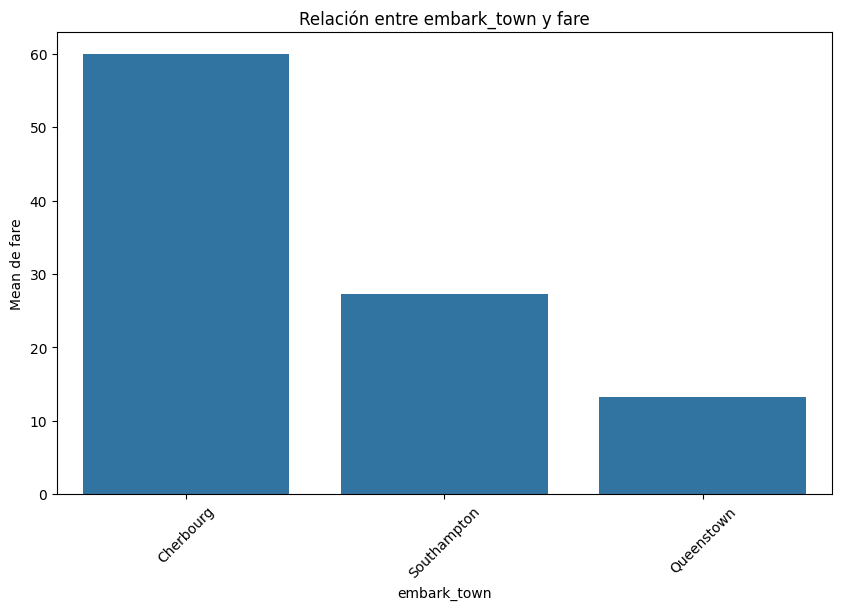

In [128]:
plot_categorical_numerical_relationship(df_titanic, "embark_town", "fare")


In [129]:
columnas = ["fare","embark_town","alive"] 
col_directora = "alive"
col_1 = [col for col in columnas if col != col_directora][0]
col_2 = [col for col in columnas if col != col_directora][1]
diccionario_multivariante = {}
for valor in df_titanic[col_directora].unique():
    diccionario_multivariante[valor] = df_titanic.loc[df_titanic[col_directora] == valor,[col_2,col_1]]

Respuesta no:


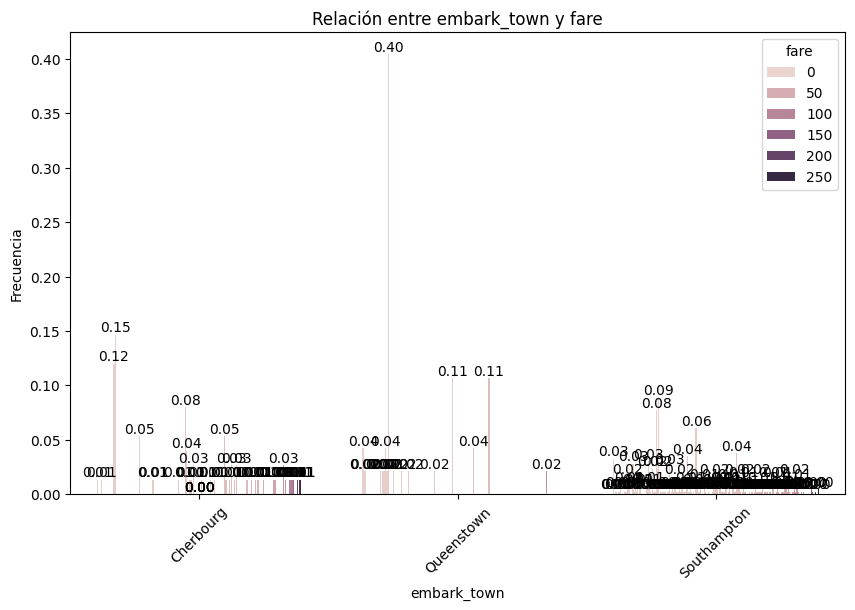

Respuesta yes:


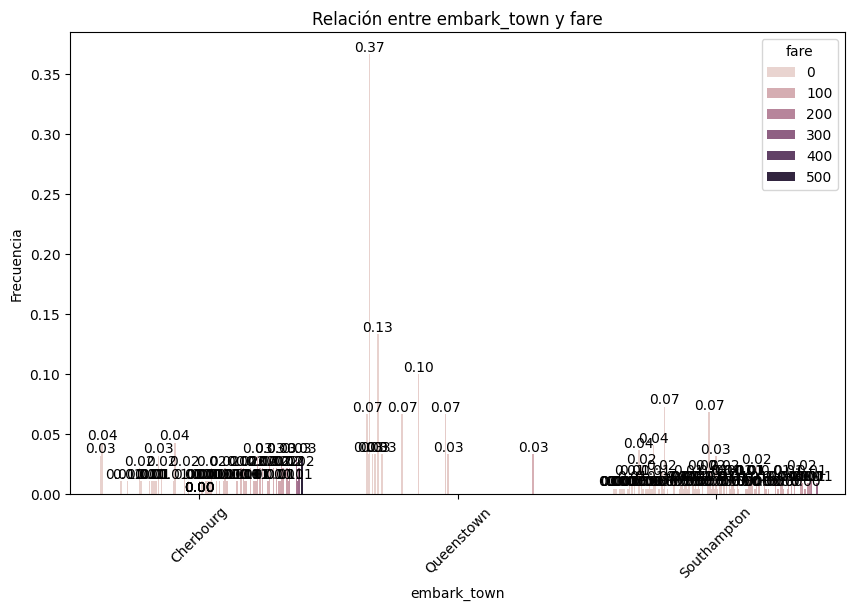

In [130]:
for valor,df_datos in diccionario_multivariante.items():
    print(f"Respuesta {valor}:")
    plot_categorical_relationship_fin(df_datos,col_2,col_1, relative_freq= True, show_values= True)

7. Ahondando en la relación entre sobrevivir o fallecer, la clase en la que se viajó y la edad de los pasajeros. ¿Qué agrupación de las dos variables (clase y edad) sobrevivió más en términos absolutos y en términos relativos?

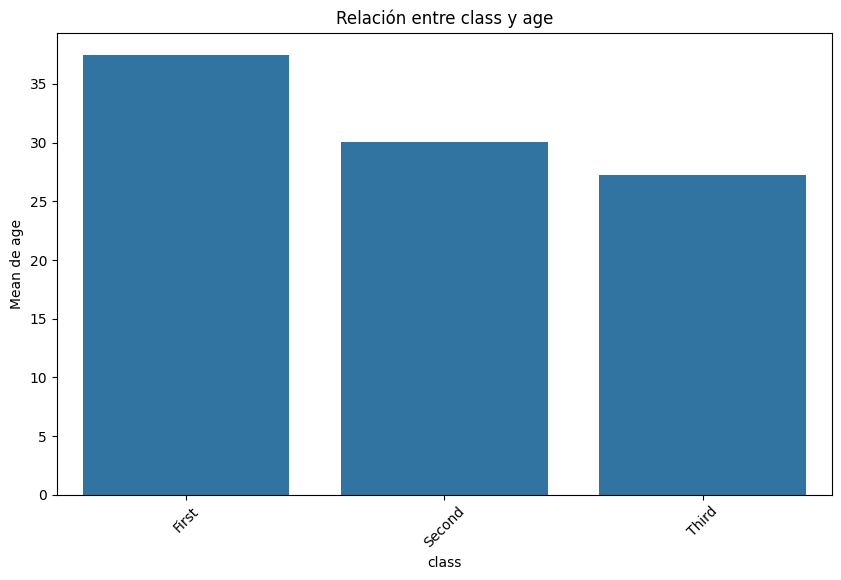

In [131]:
plot_categorical_numerical_relationship(df_titanic, "class", "age")

In [147]:
columnas = ["alive","class","age"] 
col_directora = "class"
col_1 = [col for col in columnas if col != col_directora][0]
col_2 = [col for col in columnas if col != col_directora][1]
diccionario_multivariante = {}
for valor in df_titanic[col_directora].unique():
    diccionario_multivariante[valor] = df_titanic.loc[df_titanic[col_directora] == valor,[col_2,col_1]]

Respuesta Third:


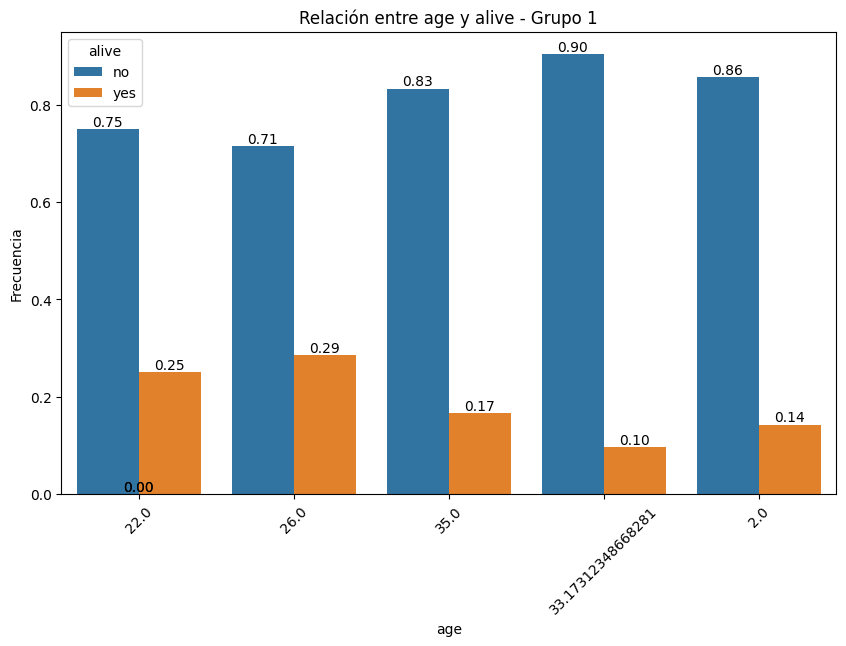

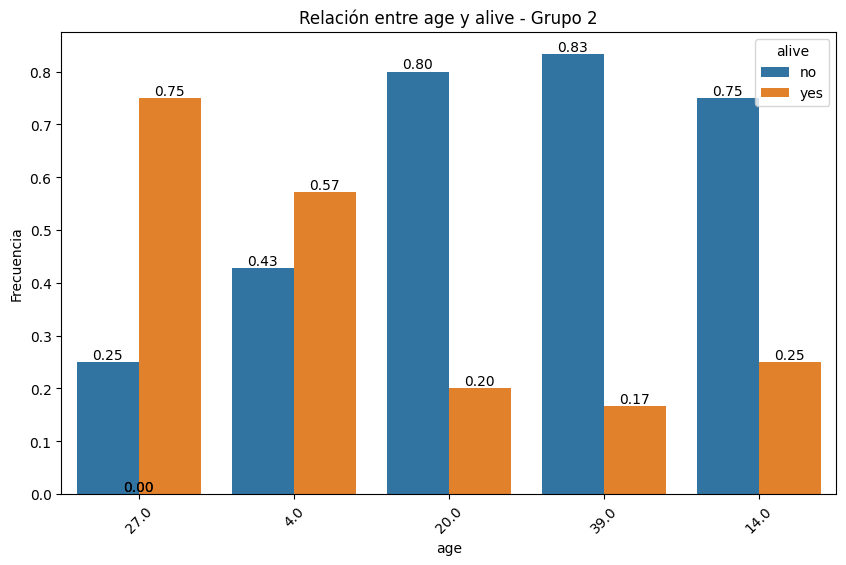

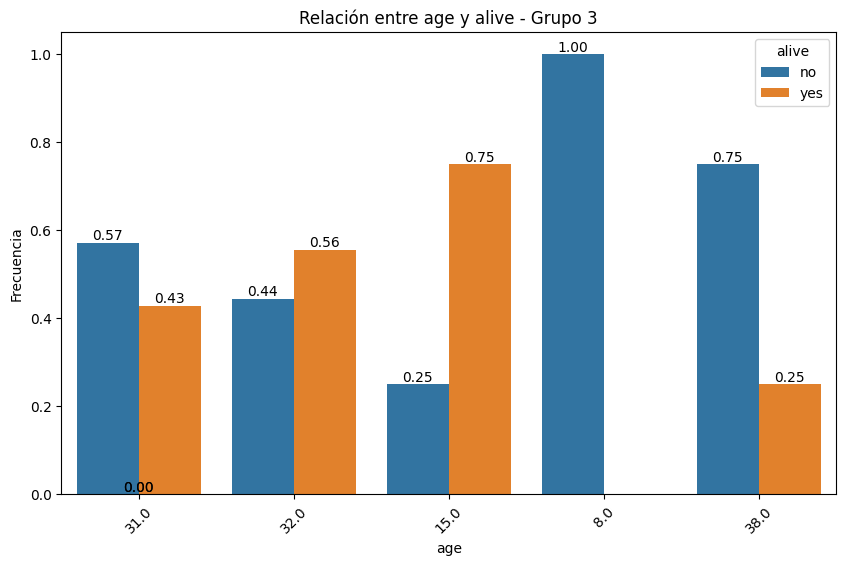

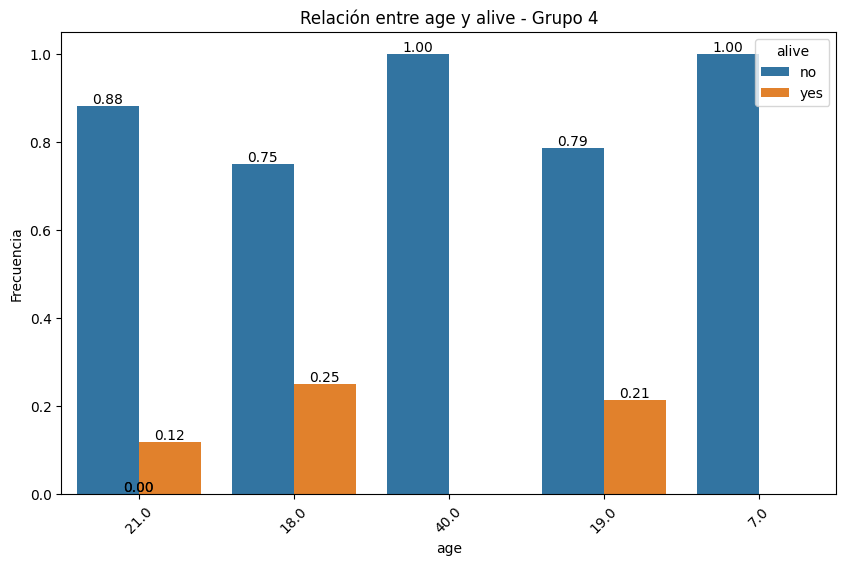

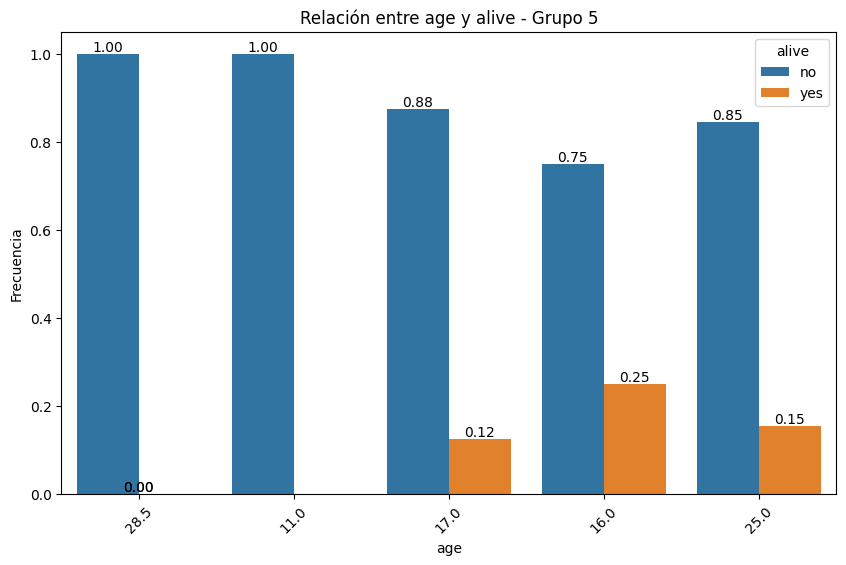

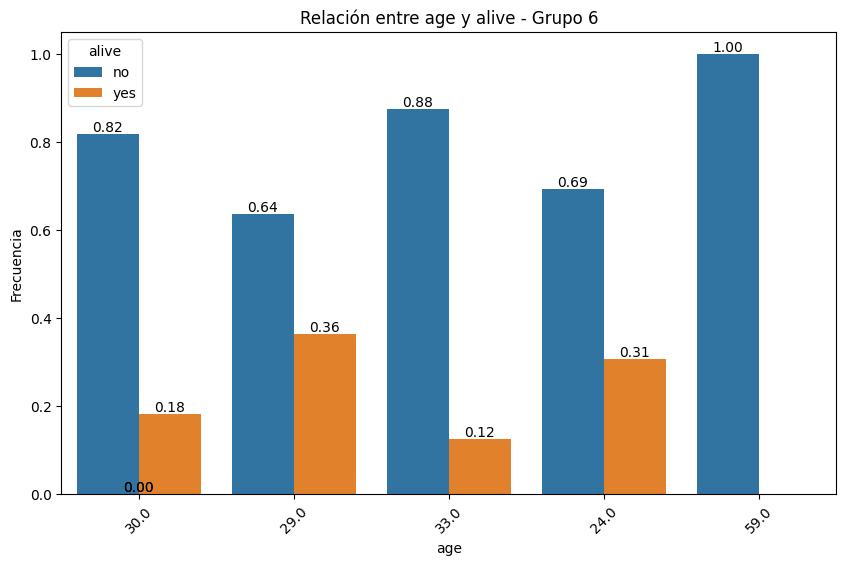

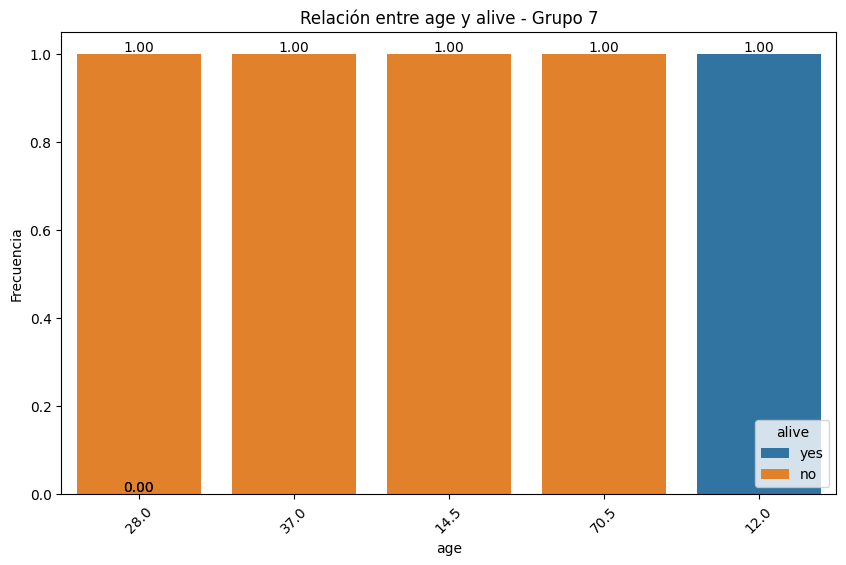

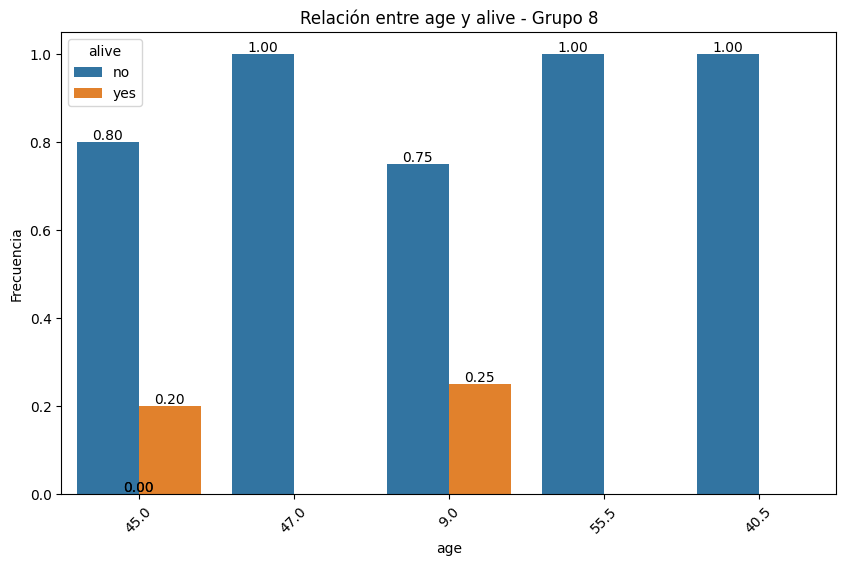

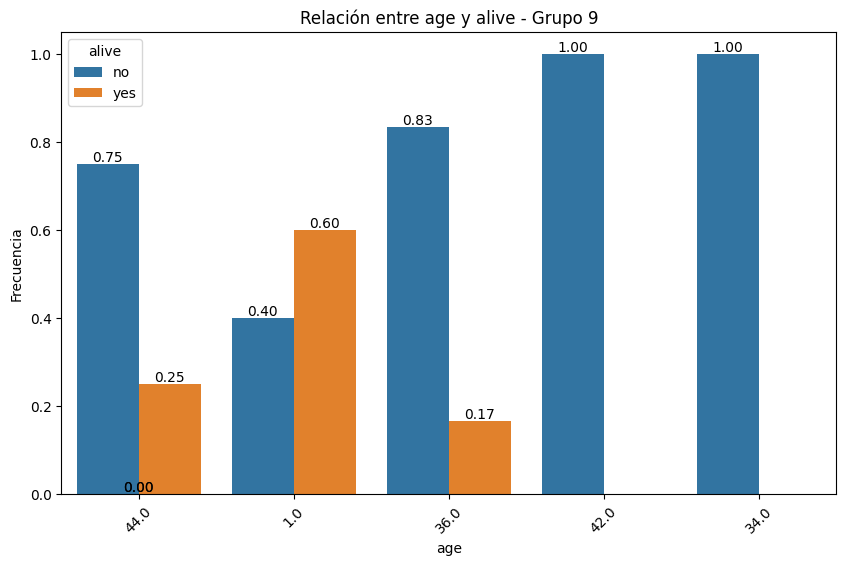

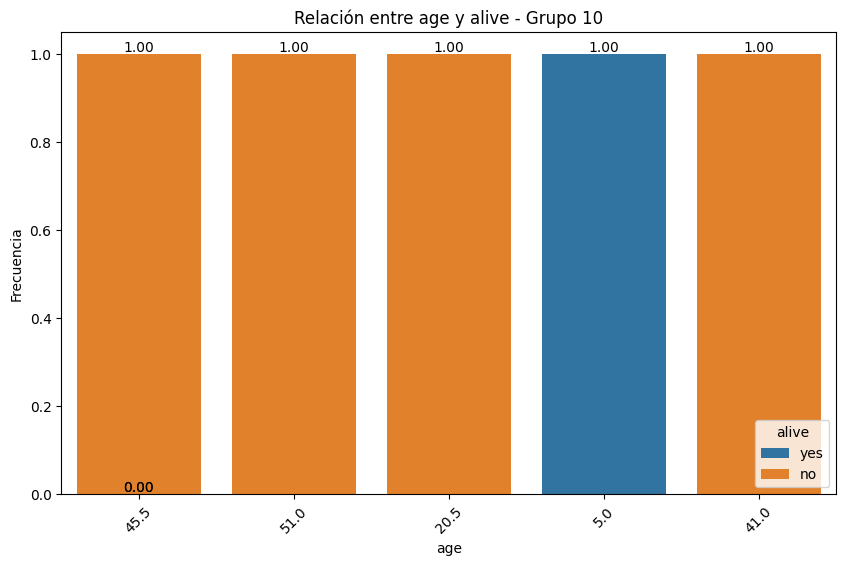

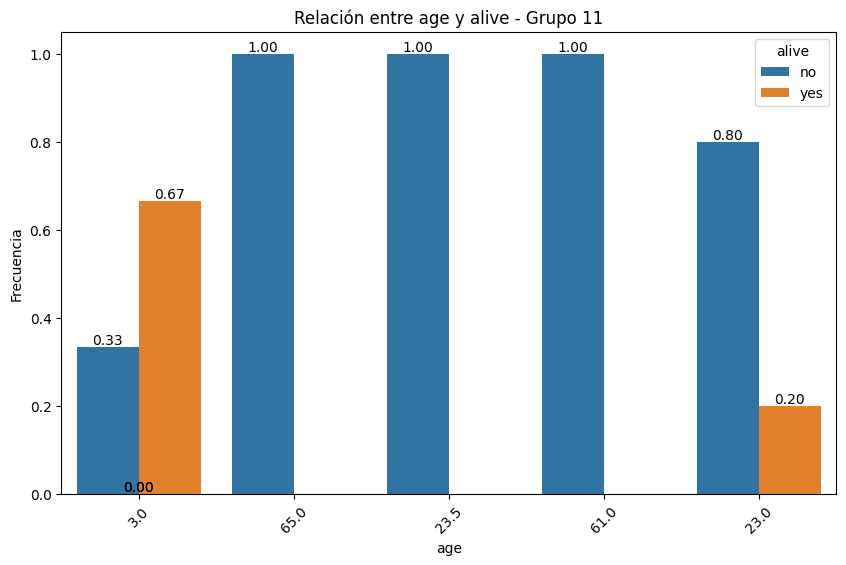

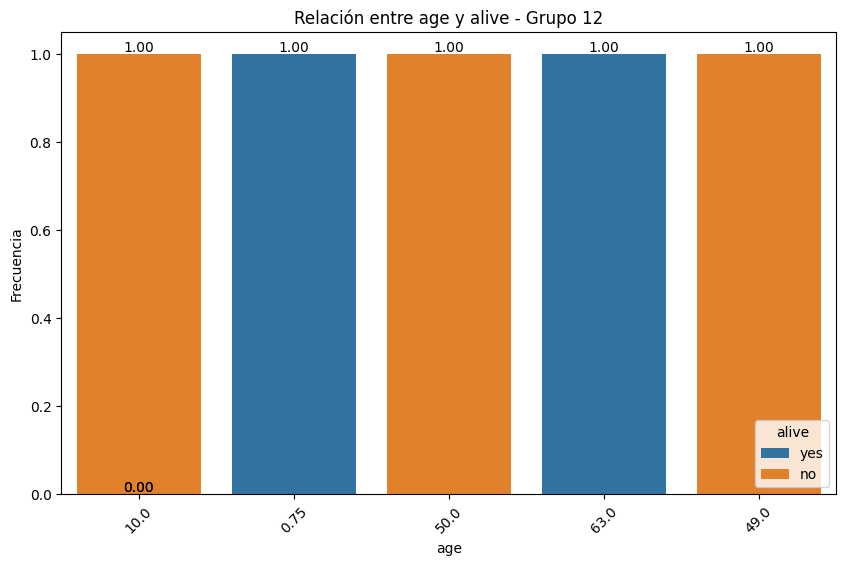

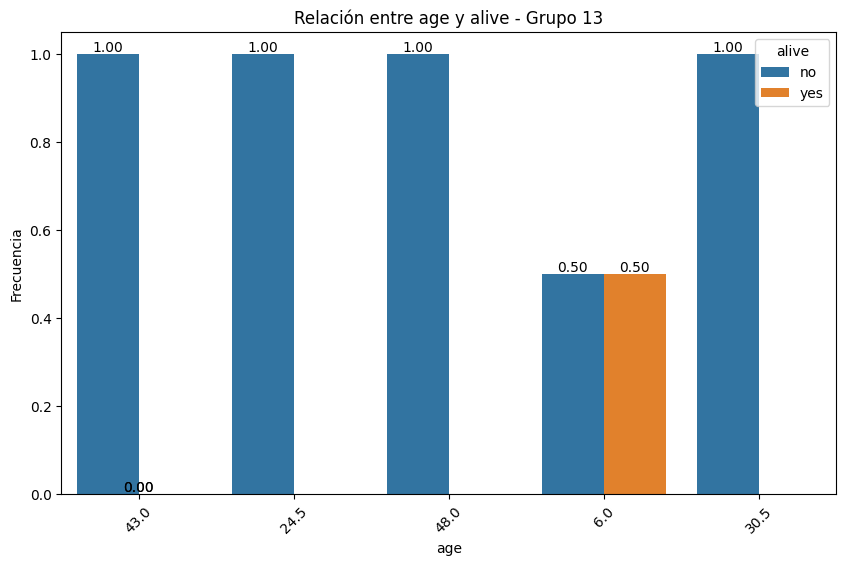

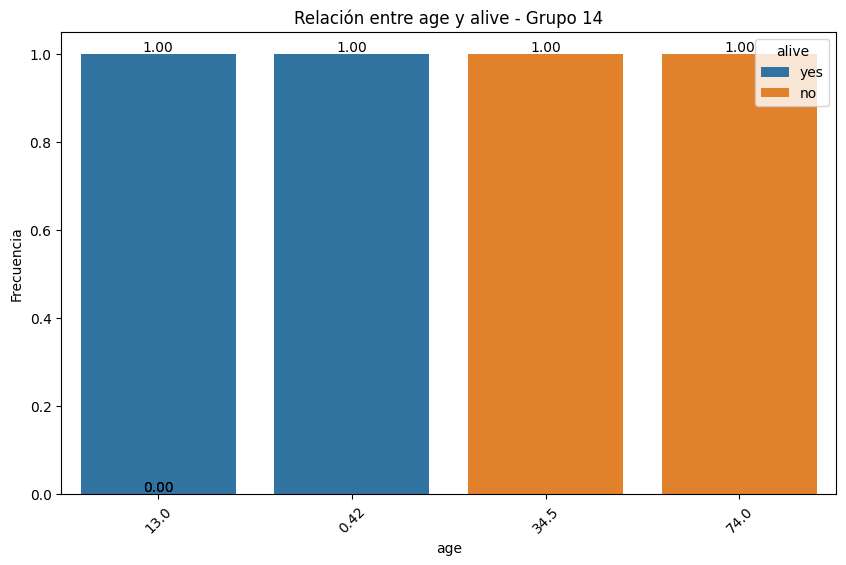

Respuesta First:


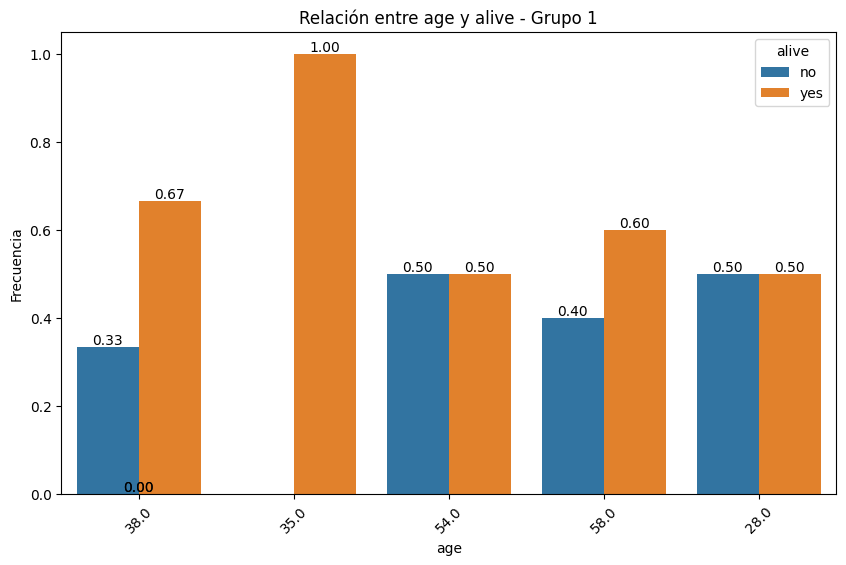

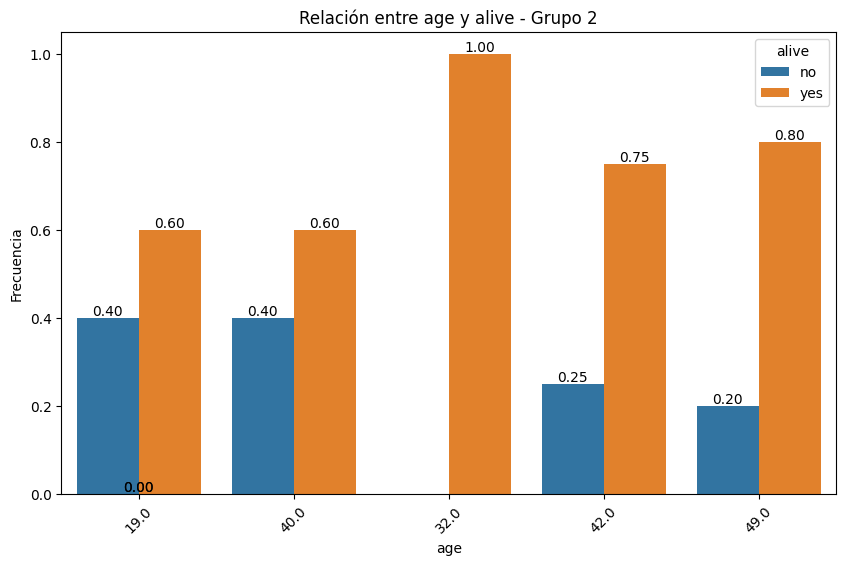

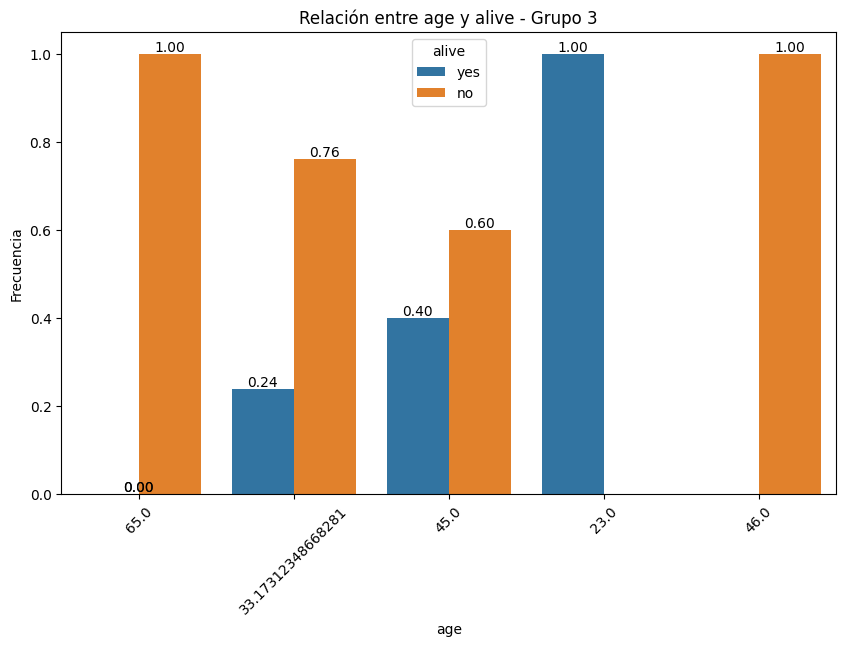

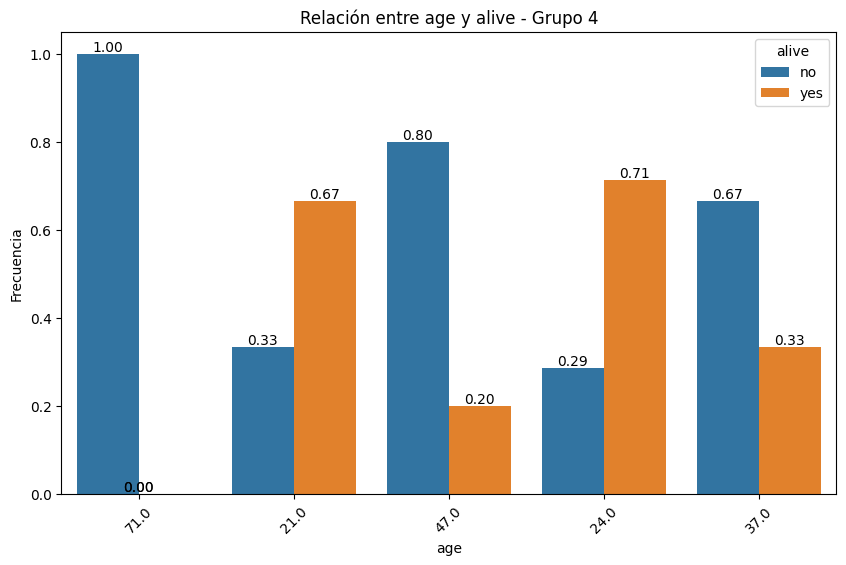

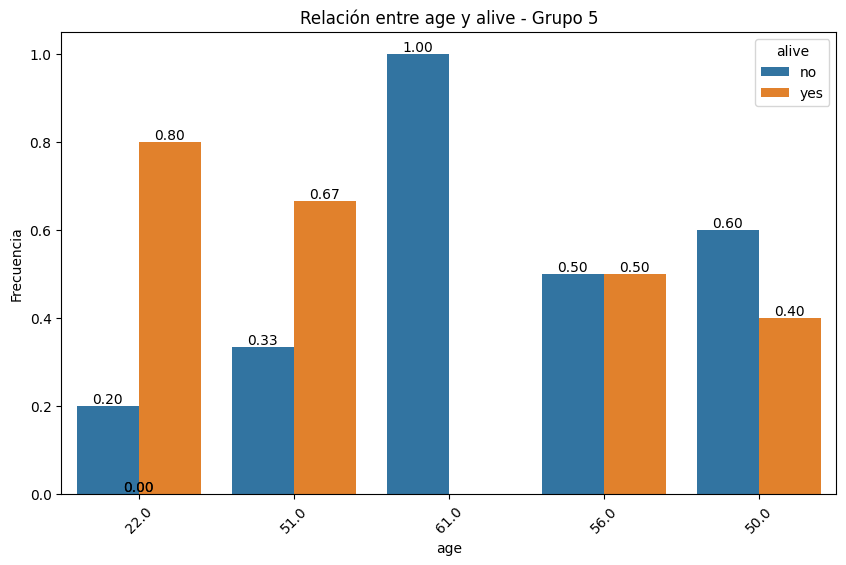

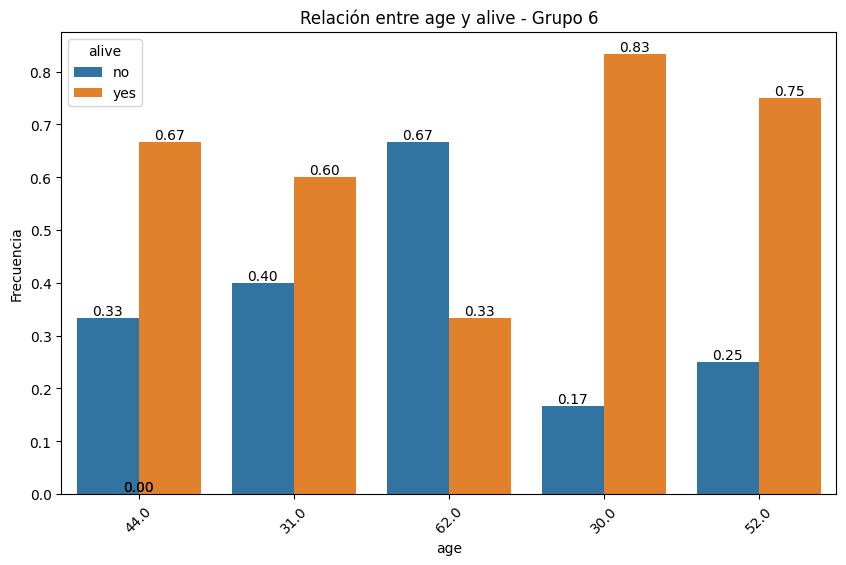

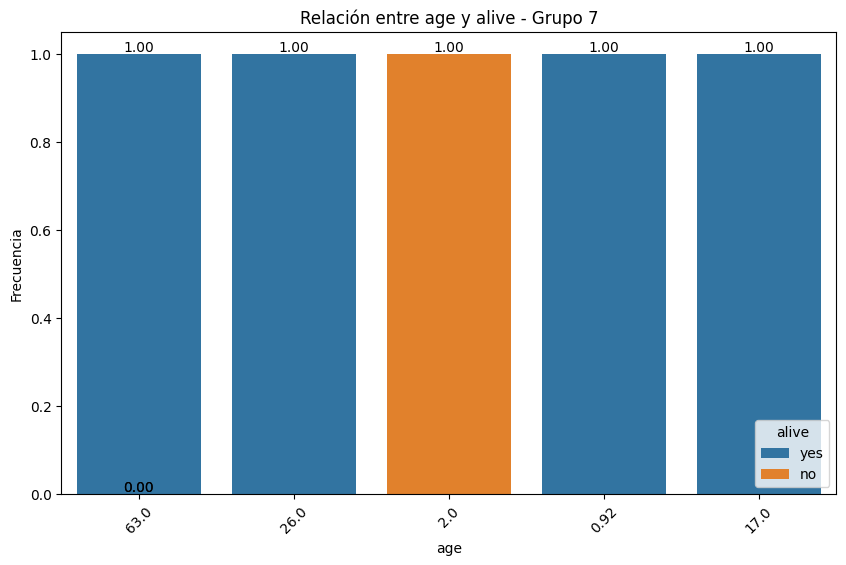

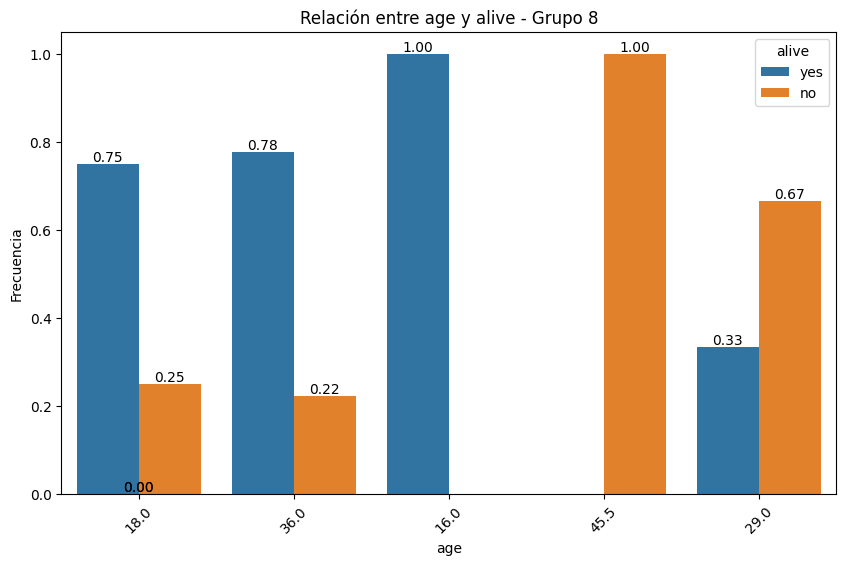

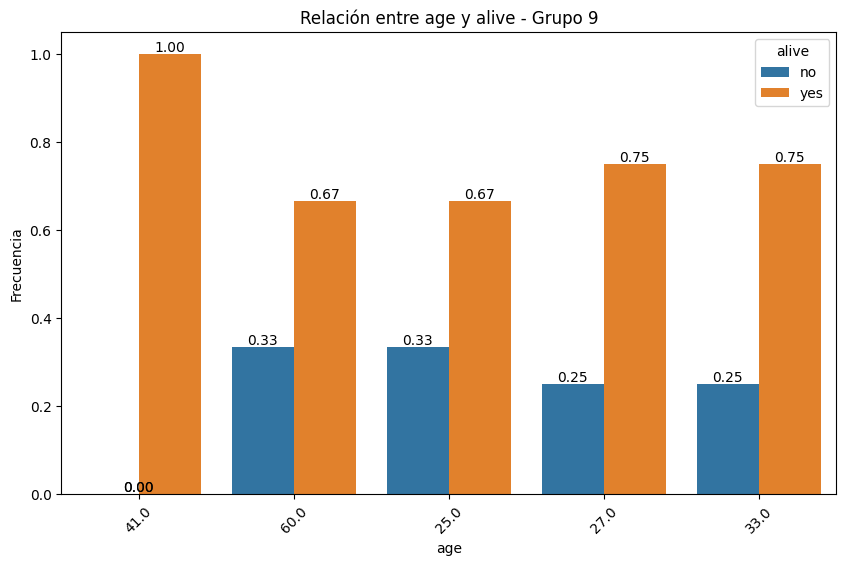

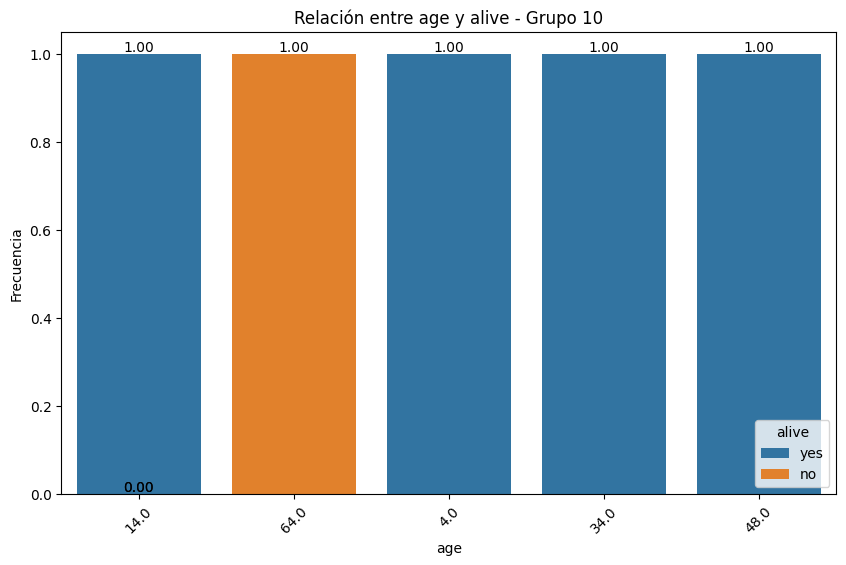

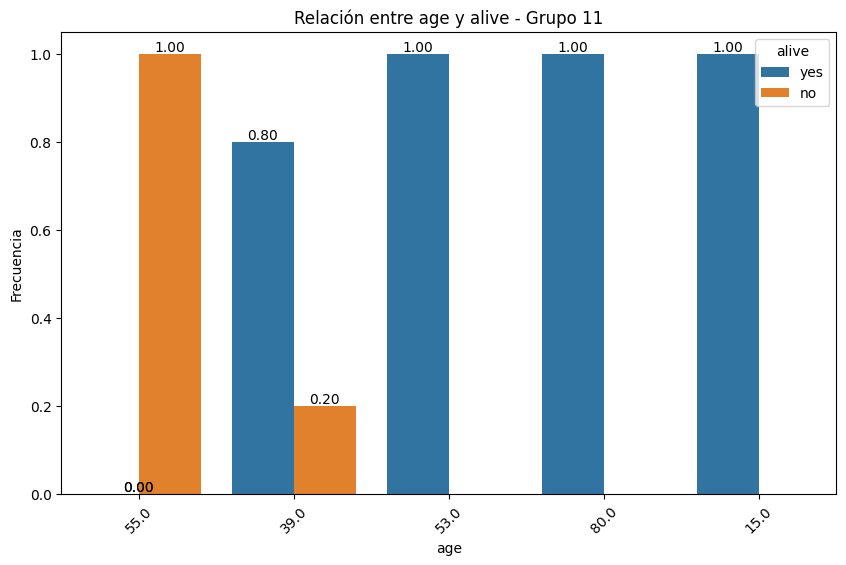

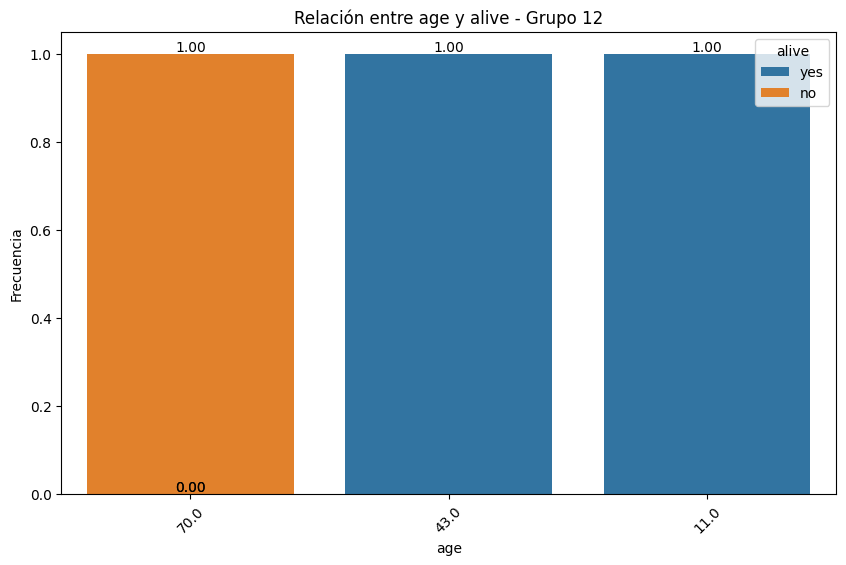

Respuesta Second:


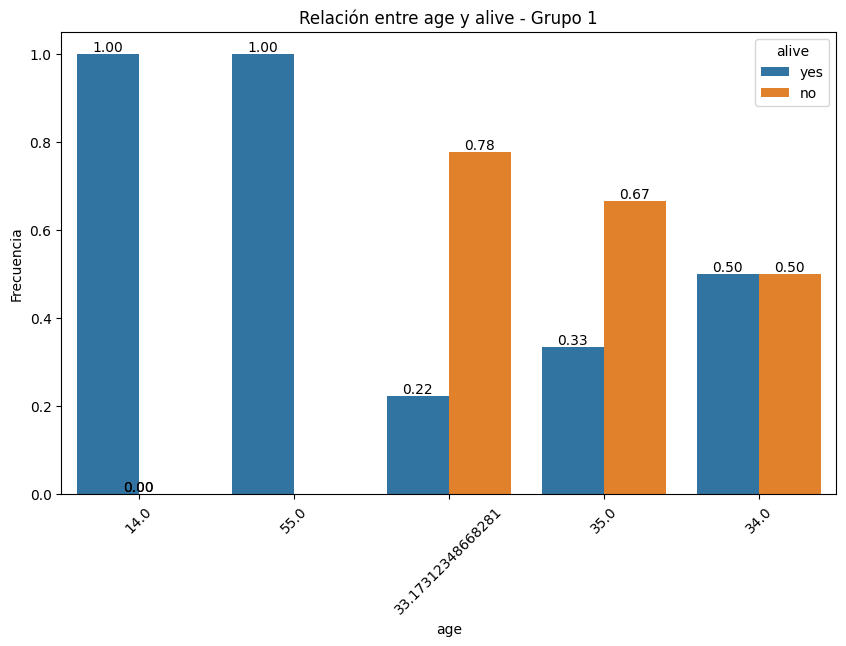

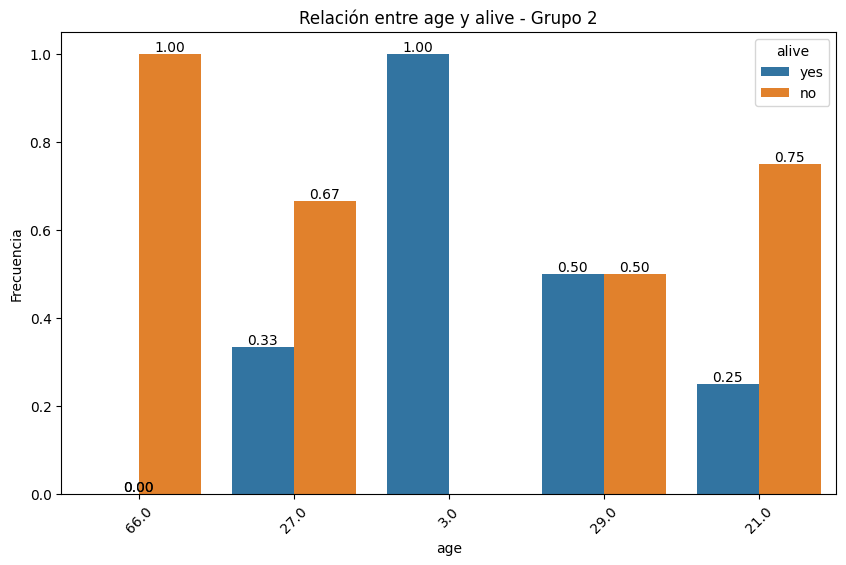

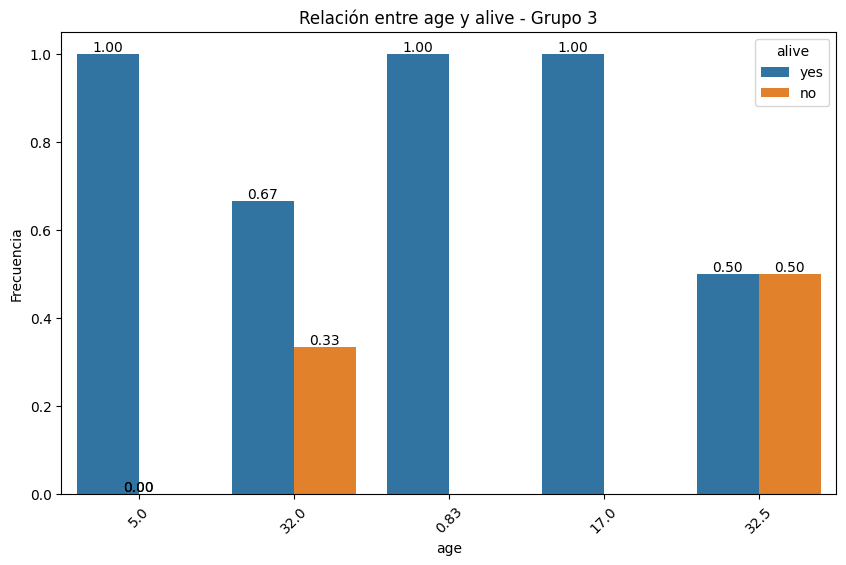

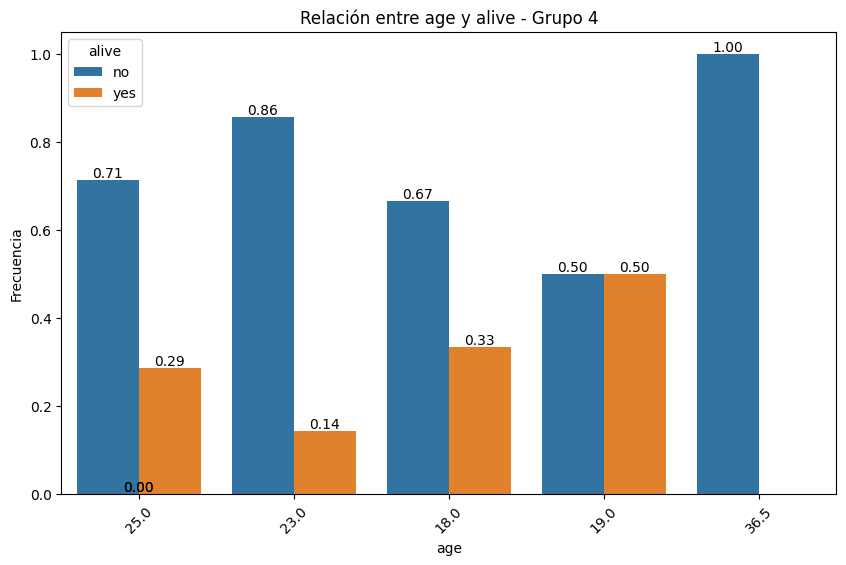

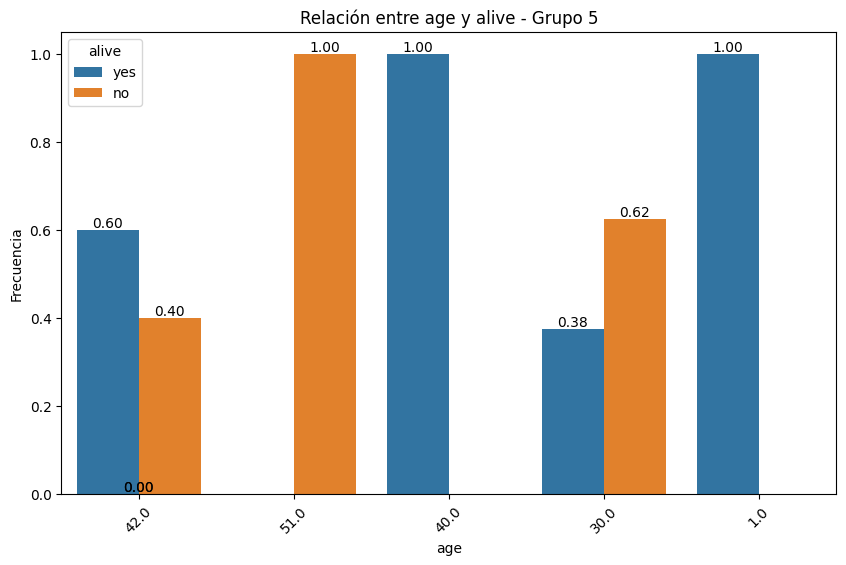

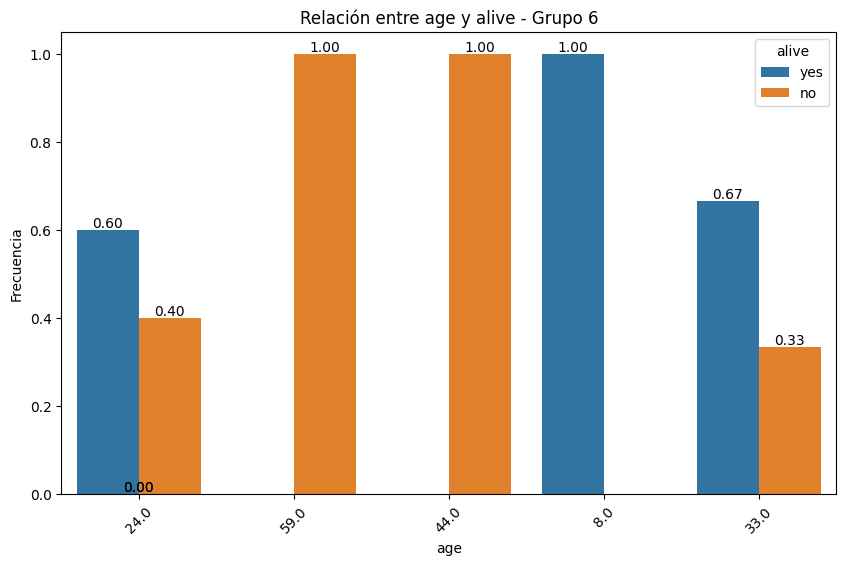

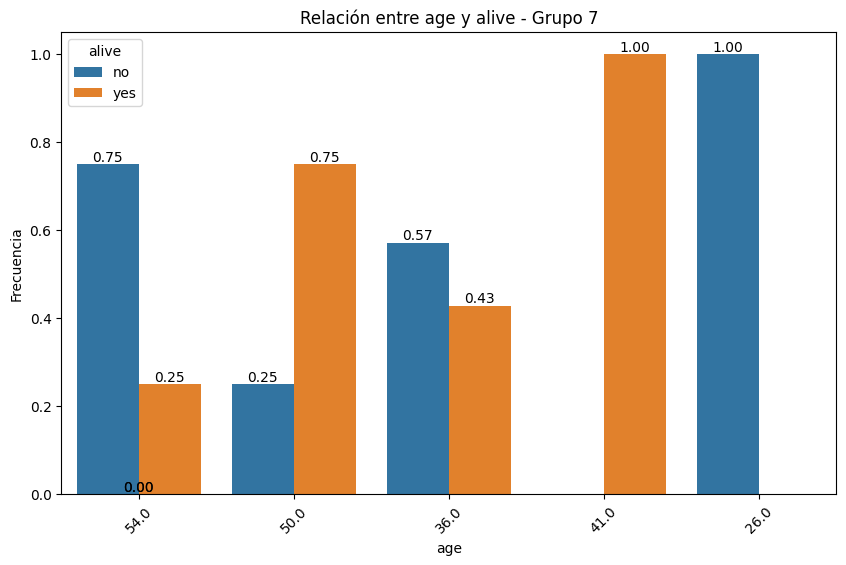

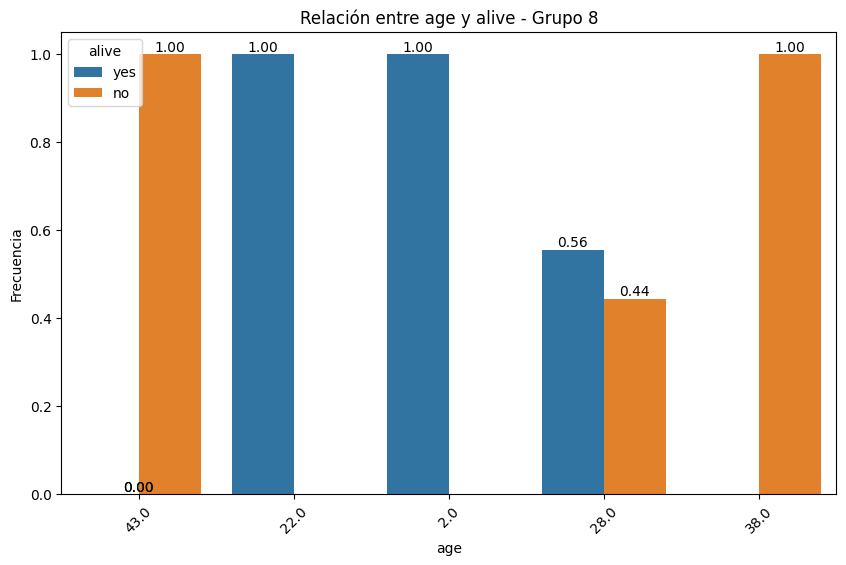

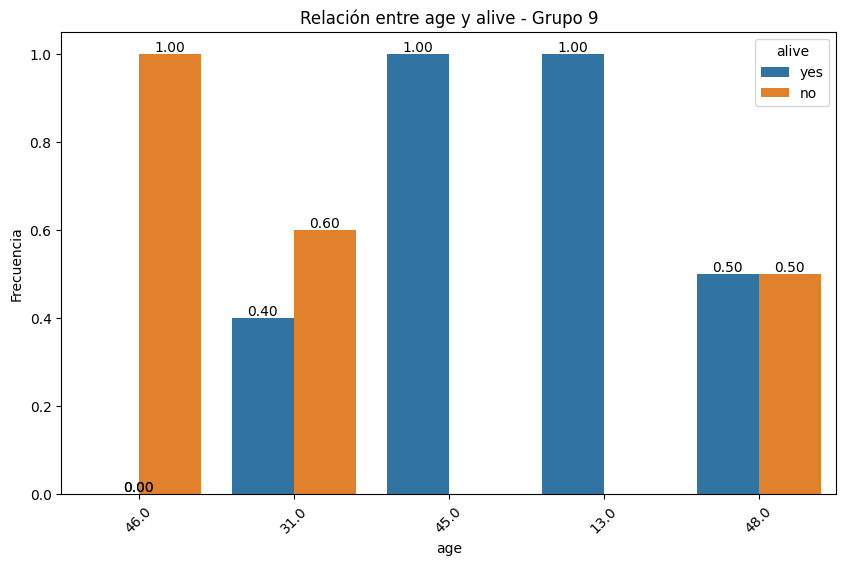

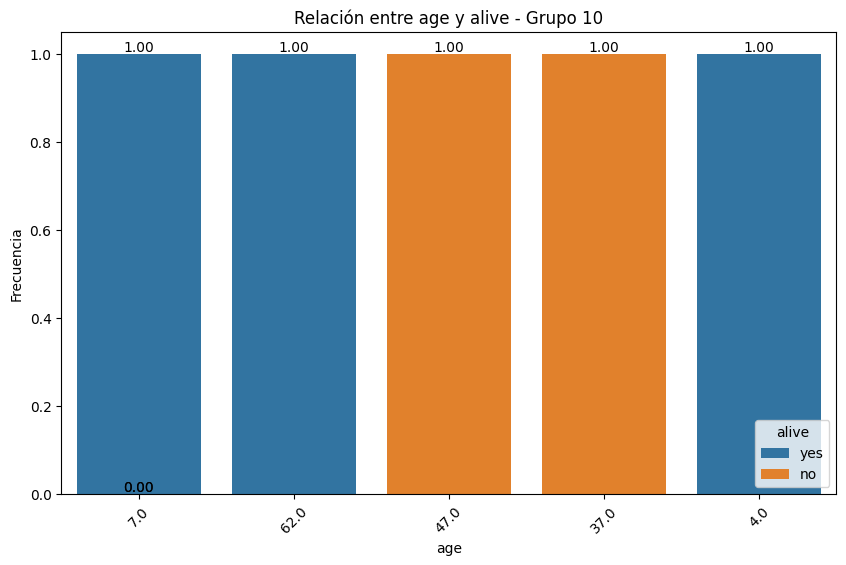

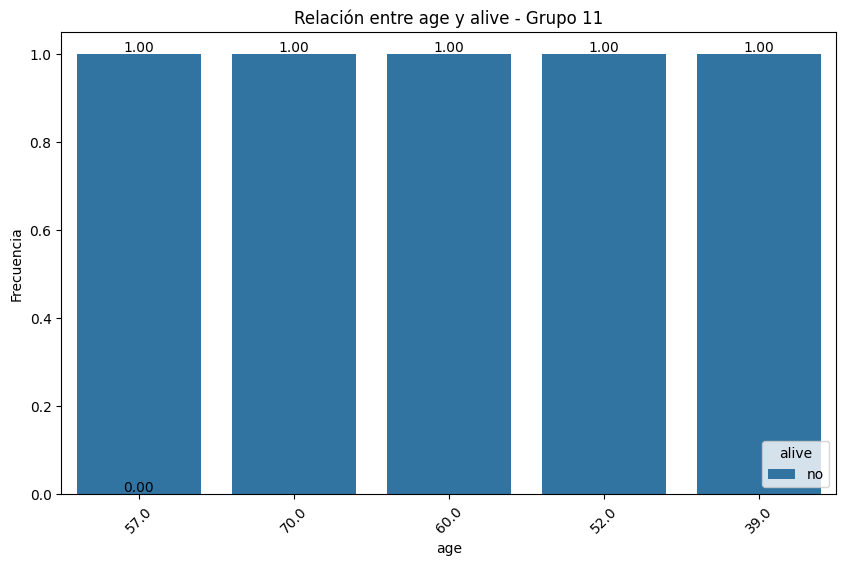

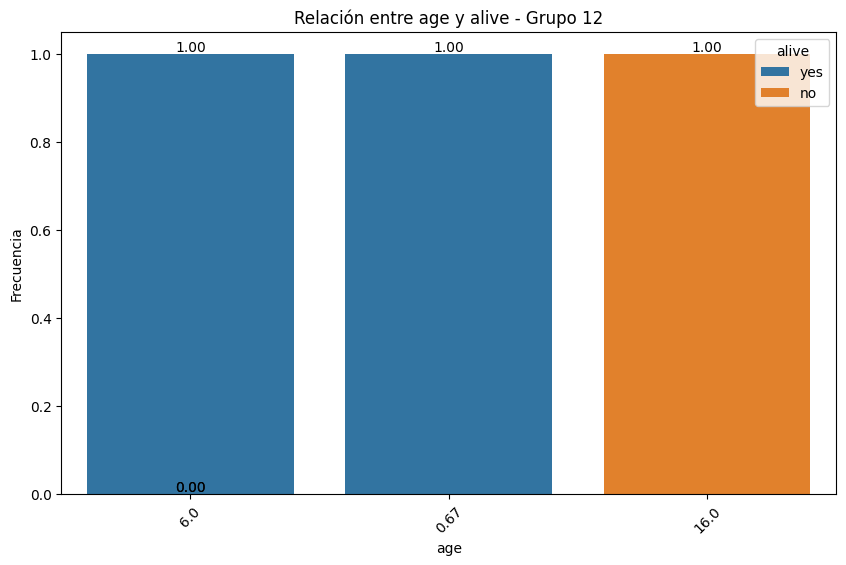

In [148]:
for valor,df_datos in diccionario_multivariante.items():
    print(f"Respuesta {valor}:")
    plot_categorical_relationship_fin(df_datos,col_2,col_1, relative_freq= True, show_values= True)

## #EXTRA: Viajes

El objetivo en este caso no es tanto hacer un montón de análisis sino de completar lo que quedó pendiente en el workout y de entender cómo de un dataset podemos obtener preguntas o hipótesis interesantes (si las hay)

### #EXTRA.1 

Carga el dataset de viajes del mes de junio. Repite el análisis bivariante entre las variables "Aircompany" e "Ingresos", mostrando previamente los viajes por compañía aérea. ¿Qué situación llamativa nos surgió? (Ten en cuenta que somos el departamenteo de DataScience de TabarAir)

### #EXTRA.2

Repite el análisis multivariante entre "ingresos","distancias" y "consumo_kg". ¿Qué veíamos que parecía también muy prometedor?

### #EXTRA.3

Crea una variable categorica "cat_vuelo" a partir de distancias, escoge los rangos de las categorías basándote en la distribución de valores de "distancia" (sugerencia entre 3 y 4 categorías). Extra: Reaiza ahora otra vez el análisis multivariante "cat_vuelo", "ingresos", "consumo_kg". ¿Ves algo diferente?